# Exploratory analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = 'data/housing.csv'
data = pd.read_csv(file_path)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
data.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
513,2485000,4400,3,1,2,yes,no,no,no,no,0,no,unfurnished
114,6020000,6800,2,1,1,yes,yes,yes,no,no,2,no,furnished
132,5810000,5200,3,1,3,yes,no,no,no,yes,0,no,semi-furnished
68,6860000,6000,3,1,1,yes,no,no,no,yes,1,no,furnished
18,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished


In [7]:
print("\nMissing values per column:\n", data.isnull().sum())


Missing values per column:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


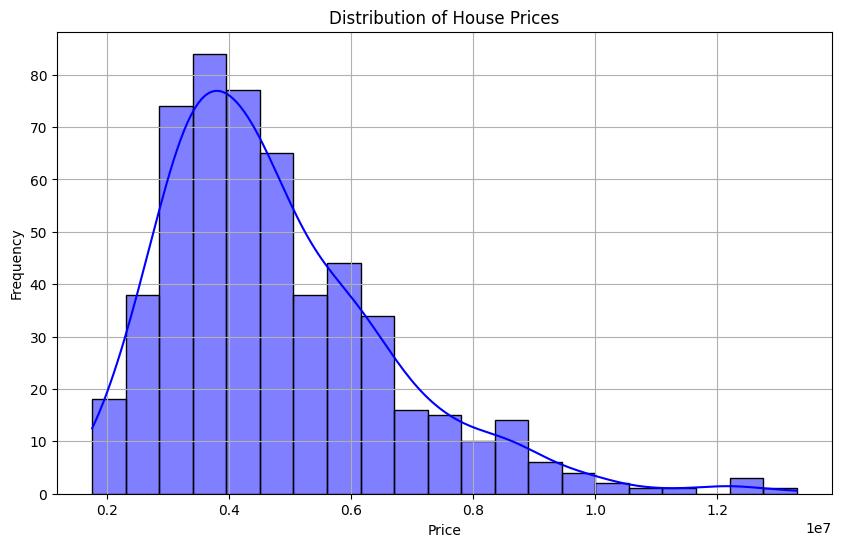

In [18]:
# Plot 1: Distribution of House Prices
# - kde=True adds a kernel density estimate line to show the distribution.
# - color specifies the color of the histogram.
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')  # Title of the plot
plt.xlabel('Price')  # Label for the x-axis
plt.ylabel('Frequency')  # Label for the y-axis
plt.grid(True)  # Adds grid lines to the plot
plt.show()

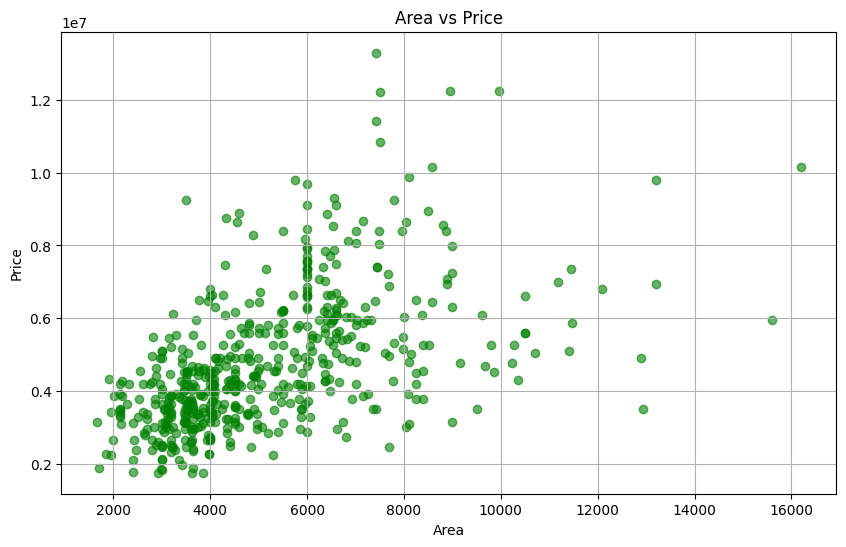

In [19]:
# Plot 2: Scatter Plot of Area vs Price
# - alpha sets the transparency of the points.
# - c sets the color of the points.
plt.figure(figsize=(10, 6))
plt.scatter(data['area'], data['price'], alpha=0.6, c='green')
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.grid(True)
plt.show()

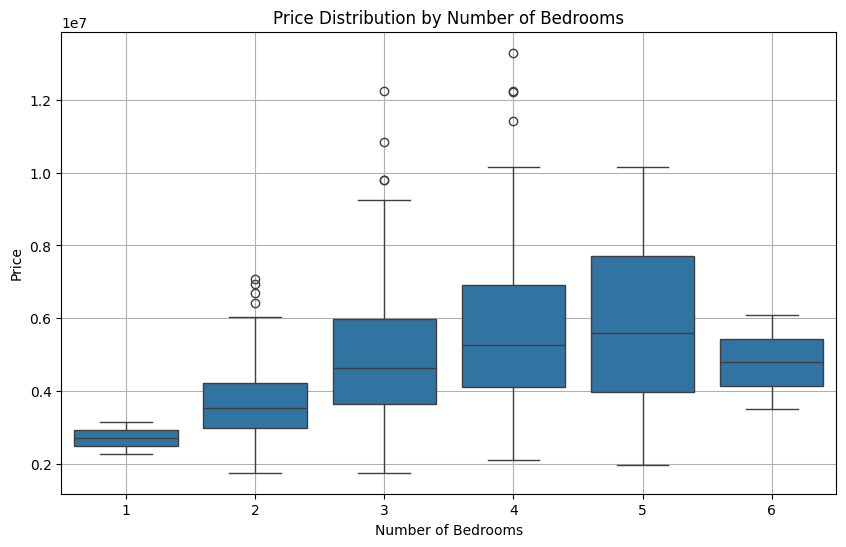

In [20]:
# Plot 3: Boxplot for Price by Number of Bedrooms
# - x and y specify the categorical and numerical variables.
# - data specifies the dataset to use.
plt.figure(figsize=(10, 6))
sns.boxplot(x='bedrooms', y='price', data=data)
plt.title('Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.grid(True)
plt.show()

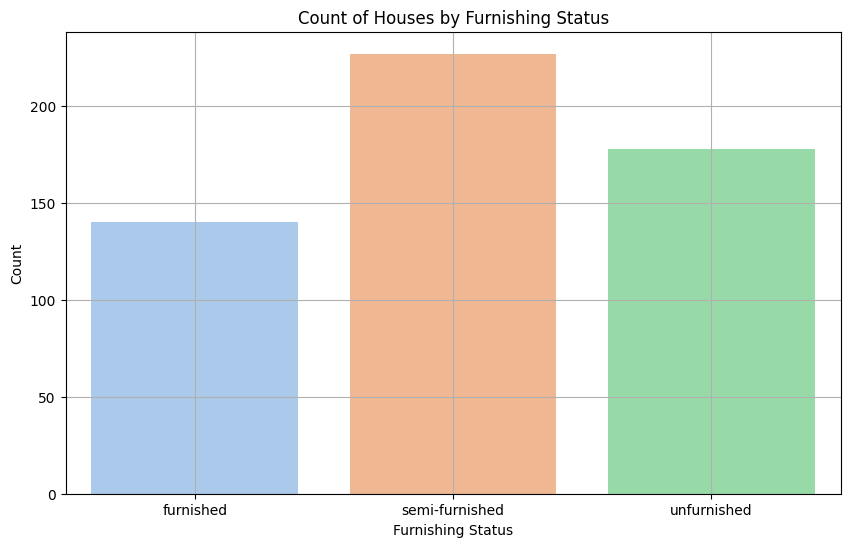

In [25]:
# Plot 4: Countplot for Furnishing Status
# - palette sets the color scheme for the bars.
plt.figure(figsize=(10, 6))
sns.countplot(x='furnishingstatus', hue="furnishingstatus", data=data, palette='pastel')
plt.title('Count of Houses by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Count')
plt.grid(True)
plt.show()

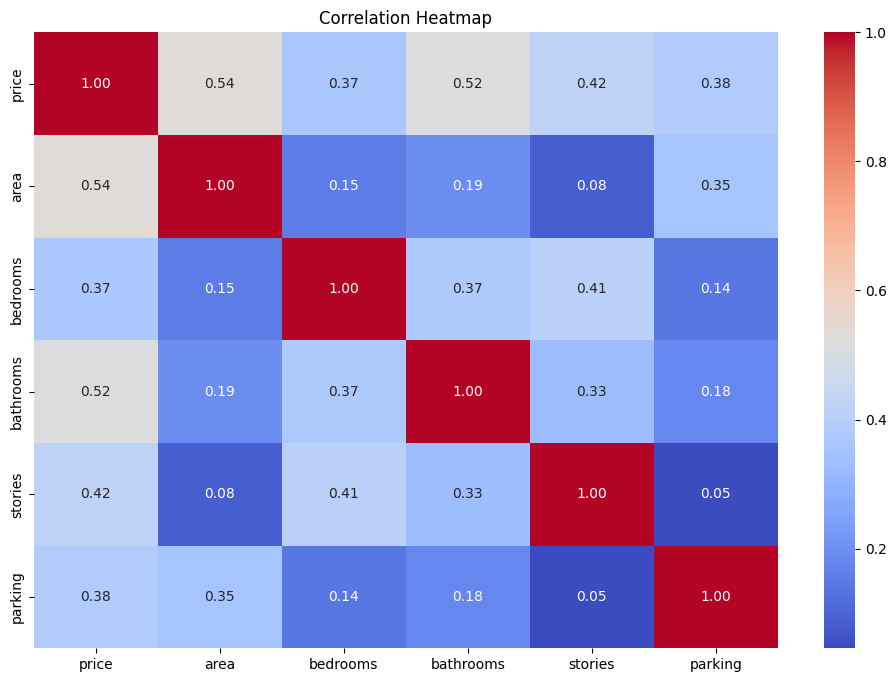

In [26]:
# Plot 5: Correlation Heatmap
# - Use only numeric columns for correlation matrix.
# - annot=True displays the correlation coefficients on the heatmap.
# - fmt='.2f' formats the numbers to 2 decimal places.
# - cmap specifies the color map.
# - cbar adds a color bar to the side.
plt.figure(figsize=(12, 8))
numeric_data = data.select_dtypes(include=['float64', 'int64'])  # Select only numeric columns
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

# Linear Algebra

In [34]:
import numpy as np
import time
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

In [28]:
A = np.random.rand(200, 300)  # 200 x 300 matrix
B = np.random.rand(300, 100)  # 300 x 100 matrix

In [30]:
start_time = time.time()
result_loop = np.zeros((A.shape[0], B.shape[1]))
for i in range(A.shape[0]):
    for j in range(B.shape[1]):
        for k in range(A.shape[1]):
            result_loop[i, j] += A[i, k] * B[k, j]
loop_time = time.time() - start_time
print(f"Naive loop multiplication time: {loop_time:.4f} seconds")

Naive loop multiplication time: 1.7239 seconds


In [31]:
start_time = time.time()
result_numpy = A.dot(B) # A @ B
numpy_time = time.time() - start_time
print(f"NumPy dot multiplication time: {numpy_time:.4f} seconds")

NumPy dot multiplication time: 0.0025 seconds


In [33]:
print("Shape of A:", A.shape)
A_T = A.T
print("Shape of A transpose:", A_T.shape)

Shape of A: (200, 300)
Shape of A transpose: (300, 200)


In [35]:
# Reshape A into a new shape (e.g., 60, 1000) if it matches total size
# (200 x 300 = 60,000). For demonstration, let's do (400, 150) (also 60,000).
A_reshaped = A.reshape(400, 150)
print("Shape of A reshaped:", A_reshaped.shape)

Shape of A reshaped: (400, 150)


In [36]:
url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/JPEG_example_flower.jpg"
response = requests.get(url)  # Make HTTP GET request
image = Image.open(BytesIO(response.content))  # Open as a PIL image object

In [37]:
img_array = np.array(image)

In [44]:
def plot_image(img_array):
    plt.figure(figsize=(6, 4))
    plt.imshow(img_array)
    plt.title("Original Image")
    plt.axis('off')  # Hide axis ticks for clarity
    plt.show()

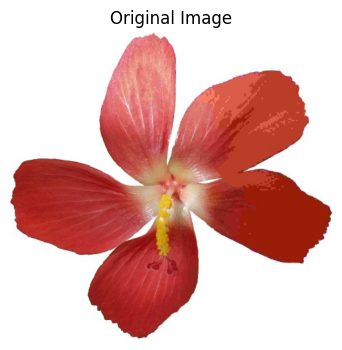

In [45]:
plot_image(img_array)

In [42]:
print("Image shape (Height, Width, Channels):", img_array.shape)

Image shape (Height, Width, Channels): (477, 500, 3)


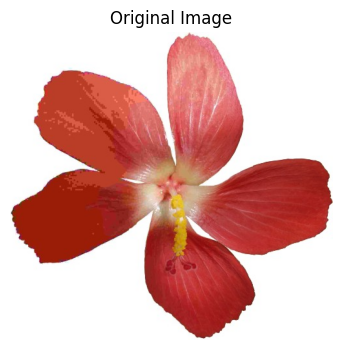

In [46]:
img_flipped_lr = np.flip(img_array, axis=1)
plot_image(img_flipped_lr)

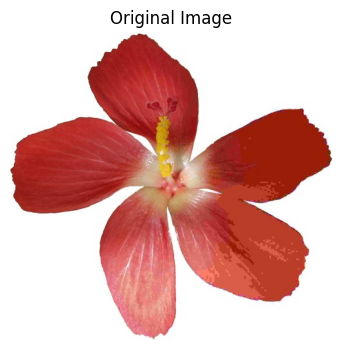

In [50]:
img_flipped_ud = np.flip(img_array, axis=0)
plot_image(img_flipped_ud)

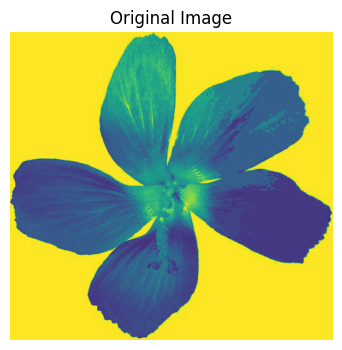

In [51]:
img_gray = np.mean(img_array, axis=2).astype(np.uint8)
plot_image(img_gray)

# Pytorch

In [125]:
import torch.nn as nn

class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(10, 1)
    
    def forward(self, x):
        return self.fc(x)
    
model = SimpleModel()

In [117]:
import pandas as pd
import numpy as np

np.random.seed(42)
data = {
    'feature1': np.random.rand(100),
    'feature2': np.random.rand(100),
    'target': np.random.randint(0, 2, size=100)  # Binary target (0 or 1)
}
df = pd.DataFrame(data)

print(df.head())

   feature1  feature2  target
0  0.374540  0.031429       1
1  0.950714  0.636410       1
2  0.731994  0.314356       0
3  0.598658  0.508571       0
4  0.156019  0.907566       1


In [118]:
import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe
        self.features = dataframe[['feature1', 'feature2']].values  # Inputs
        self.labels = dataframe['target'].values                   # Targets

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return features and labels as tensors
        x = torch.tensor(self.features[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)  # For classification
        return x, y

# Create dataset
dataset = CustomDataset(df)

In [119]:
from torch.utils.data import DataLoader

# Create DataLoader
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Check a batch
for batch in dataloader:
    features, labels = batch
    print("Features:", features)
    print("Labels:", labels)
    break

Features: tensor([[0.3117, 0.6096],
        [0.8287, 0.6335],
        [0.6011, 0.2288],
        [0.6119, 0.8074],
        [0.0581, 0.4104],
        [0.5227, 0.7260],
        [0.0344, 0.4972],
        [0.9219, 0.2421],
        [0.0885, 0.6721],
        [0.1079, 0.7799],
        [0.9699, 0.1612],
        [0.7852, 0.4271],
        [0.9507, 0.6364],
        [0.1834, 0.8715],
        [0.8324, 0.9297],
        [0.1960, 0.7616]])
Labels: tensor([0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1])
